# Week 4 · Communities and seeing networks *(catch-up)*

Filled after class, 23 Sep 2026. You did not work these live. Source: [week 4](https://sunelehmann.com/socialgraphs2026-web/weeks/week4). Last content week before **Test 1** (30 Sep, weeks 1–4).

**Catch-up rule.** Learn items are closed-book study notes (definition → method → numbers → what would change). Tool items are run on the frozen philosopher snapshot in this folder. Optional **4.4** and stretch **4.12** are skipped. **4.13** is the group go-nuts post (not a personal notebook item).

**Representation.** Node = Wikipedia page of a philosopher born before 1900. Directed edge = a wiki-link in the *article text* (not navboxes), weight = how many times. The week works with the **undirected** graph obtained by summing both directions. Unless a cell says otherwise we use the **giant component**: $n=1374$, $m=9139$.

Formulas you need on the test are printed on the paper. The skill is *using* them, not memorizing them.


## Shared graph for 4.1, 4.3, 4.10

Nodes A–G, $m=8$ unweighted links: A–B, A–C, B–C, C–D, D–E, D–F, E–F, F–G.

```
A --- B
 \   /
  \ /
   C --- D --- E
          \   /
           \ /
            F --- G
```

Degrees: $k_A=k_B=k_E=2$, $k_C=k_D=k_F=3$, $k_G=1$. Number of pairs: $\binom{7}{2}=21$.


## 4.1 — Cutting by hand *(catch-up, Learn)*

**Asked.** Edge betweenness by counting; first Girvan–Newman cut; recompute; dendrogram; why recompute.

**On the test.** Count shortest paths on a small drawing. Say which link is removed first, and why the algorithm recomputes after every cut.


**Catch-up (not done live).** Closed-book takeaway: a bridge between two dense blobs carries *every* cross pair, so it wins. After you cut it, that traffic is gone — leftover “high” values from the first pass are stale. Always recompute.

### 1. Betweenness of every link

No ties: each of the 21 pairs has a unique shortest path. Add $1$ to every link on that path.

| Pair | Path | Pair | Path | Pair | Path |
| --- | --- | --- | --- | --- | --- |
| A–B | AB | B–C | BC | D–E | DE |
| A–C | AC | B–D | BCD | D–F | DF |
| A–D | ACD | B–E | BCDE | D–G | DFG |
| A–E | ACDE | B–F | BCDF | E–F | EF |
| A–F | ACDF | B–G | BCDFG | E–G | EFG |
| A–G | ACDFG | C–D | CD | F–G | FG |
| | | C–E | CDE | | |
| | | C–F | CDF | | |
| | | C–G | CDFG | | |

Tally:

| Link | Count | Why, in one line |
| --- | --- | --- |
| A–B | $1$ | only the pair A–B |
| A–C | $5$ | A to $\{C,D,E,F,G\}$ |
| B–C | $5$ | B to $\{C,D,E,F,G\}$ |
| **C–D** | **$12$** | every pair between $\{A,B,C\}$ and $\{D,E,F,G\}$: $3\times 4=12$ |
| D–E | $4$ | A–E, B–E, C–E, D–E |
| D–F | $8$ | three left-nodes to F and to G, plus D–F and D–G |
| E–F | $2$ | E–F and E–G |
| F–G | $6$ | every pair that includes G |

Check: the 21 path lengths sum to $43$, and the eight tallies sum to $43$.

**Girvan–Newman removes C–D first** (edge betweenness $12$).

Hand check worth remembering: you do *not* need all 21 paths to see that C–D wins. It is the only cut between a 3-node side and a 4-node side.

### 2. Remove C–D and recompute

The graph falls into $\{A,B,C\}$ and $\{D,E,F,G\}$. The $12$ cross pairs have no path, so they stop contributing.

| Link | After | Change |
| --- | --- | --- |
| A–B | $1$ | same |
| A–C | $1$ | $5\to 1$ (lost A to the right side) |
| B–C | $1$ | $5\to 1$ |
| D–E | $1$ | $4\to 1$ |
| D–F | $2$ | $8\to 2$ |
| E–F | $2$ | same |
| F–G | $3$ | $6\to 3$ |

**F–G is now half of what it was** because three of the six G-pairs were A–G, B–G, C–G. Those paths died with C–D. The three that remain are D–G, E–G, F–G.

Next cut: **F–G** (betweenness $3$, now the unique maximum).

### 3. Dendrogram, first two levels

- Level 1 (cut C–D): $\{A,B,C\}$ · $\{D,E,F,G\}$
- Level 2 (cut F–G): $\{A,B,C\}$ · $\{D,E,F\}$ · $\{G\}$

### 4. Why recompute every time

A removal *reroutes* remaining traffic, and it can *delete* traffic (as here: the two sides disconnect, so DF is no longer a busy bridge). If you sorted once on the original scores you would cut D–F next ($8$), which is the wrong second cut.

The week-4 explorable makes the same point: the last link between groups of $68$ and $32$ carries exactly $68\times 32=2176$ shortest paths, then the recomputed top value drops to $183$.


In [1]:
# NetworkX check of the hand count (normalized=False = raw path counts)
import networkx as nx

toy = nx.Graph()
toy.add_edges_from(
    [("A", "B"), ("A", "C"), ("B", "C"), ("C", "D"), ("D", "E"), ("D", "F"), ("E", "F"), ("F", "G")]
)
print("first pass", {tuple(sorted(e)): v for e, v in nx.edge_betweenness_centrality(toy, normalized=False).items()})
toy.remove_edge("C", "D")
print("after C–D", {tuple(sorted(e)): v for e, v in nx.edge_betweenness_centrality(toy, normalized=False).items()})


first pass {('A', 'B'): 1.0, ('A', 'C'): 5.0, ('B', 'C'): 5.0, ('C', 'D'): 12.0, ('D', 'E'): 4.0, ('D', 'F'): 8.0, ('E', 'F'): 2.0, ('F', 'G'): 6.0}
after C–D {('A', 'B'): 1.0, ('A', 'C'): 1.0, ('B', 'C'): 1.0, ('D', 'E'): 1.0, ('D', 'F'): 2.0, ('E', 'F'): 2.0, ('F', 'G'): 3.0}


## 4.2 — Did you really read it? — groups *(catch-up, Learn)*

**Asked.** Community vs clique; why subtract the null; Louvain vs Zachary; two questions before believing $Q=0.35$.

**On the test.** What modularity measures (how *grouped*, not how *right*); spot a modularity with no null.


**Catch-up (not done live).** Closed-book takeaway: a community is a *tendency* to link inside a group, not a clique. $Q$ scores a proposed split against the degree-preserving null. High $Q$ is not ground truth, and a single $Q$ without a shuffle is not a finding.

1. **Community.** A set of nodes that are more densely connected among themselves than you would expect to the rest of the network (Coscia: two nodes in the same community are more likely to be linked). **“All connected to each other” is a clique.** On the philosophers that would mean each tradition is a complete subgraph. They are not: Aristotle is not linked to every ancient page. The clique definition would report only tiny complete pieces and miss the schools.

2. **Why subtract $k_ik_j/2m$.** That is the expected number of $i$–$j$ links in the configuration model (degrees fixed, stubs matched at random). If you scored a split by the *fraction of links inside groups alone*, putting everyone in one community would score $1$ every time — “perfect communities” by doing no work. Subtracting the null makes that partition score $Q=0$.

3. **Four Louvain groups scoring higher than Zachary’s two factions does not make them more real.** $Q$ is not a truth score. Each faction had an inner circle, so a four-way split can look “more grouped.” Member 8 (the black-belt student) even *raises* $Q$ if you move him against the historical label. The number does not know about the feud.

4. **Two questions before believing “modularity $0.35$, so there is community structure.”**
   - **Compared to what?** What does Louvain (or the same partition) score on a *degree-preserving shuffle* of the same $n,m$, degrees? (Philosophers: real $\approx 0.51$, shuffle $\approx 0.23$. A sparse random graph can hit $0.8$.)
   - **How stable?** Do other seeds give the same groups, measured by NMI (1 = identical, 0 = independent)? Similar $Q$ with low NMI is a score without a structure.


## 4.3 — Modularity by hand *(catch-up, Learn)*

**Asked.** $Q$ for two partitions, then the dendrogram level, $Q=0$ for one community, and why a degree-1 node sticks to its neighbour.

**On the test.** Per-community formula (printed on the paper): $Q=\sum_c \bigl[\ell_c/m - (d_c/2m)^2\bigr]$. One community $\Rightarrow Q=0$.


**Catch-up (not done live).** Closed-book takeaway: count internal links $\ell_c$ and the degree sum $d_c$ of each group. One blob always gives $Q=0$. Leaves glue to their only neighbour because that merge always raises $Q$.

Here $m=8$, $2m=16$.

### 1. Partition $\{A,B,C\}\cdot\{D,E,F,G\}$

| Community | Internal links $\ell_c$ | Degree sum $d_c$ |
| --- | --- | --- |
| ABC | AB, AC, BC $\to 3$ | $2+2+3=7$ |
| DEFG | DE, DF, EF, FG $\to 4$ | $3+2+3+1=9$ |

The missing link is the cut C–D. Check: $3+4+1=8$, $7+9=16$.

$$
Q = \Bigl[\tfrac{3}{8}-\bigl(\tfrac{7}{16}\bigr)^2\Bigr] + \Bigl[\tfrac{4}{8}-\bigl(\tfrac{9}{16}\bigr)^2\Bigr] = \tfrac{7}{8} - \tfrac{130}{256} = \tfrac{94}{256} = \tfrac{47}{128} \approx 0.367.
$$

### 2. Partition $\{A,B,C,D\}\cdot\{E,F,G\}$

| Community | $\ell_c$ | $d_c$ |
| --- | --- | --- |
| ABCD | AB, AC, BC, CD $\to 4$ | $2+2+3+3=10$ |
| EFG | EF, FG $\to 2$ | $2+3+1=6$ |

Cuts: D–E and D–F.

$$
Q = \Bigl[\tfrac{4}{8}-\bigl(\tfrac{10}{16}\bigr)^2\Bigr] + \Bigl[\tfrac{2}{8}-\bigl(\tfrac{6}{16}\bigr)^2\Bigr] = \tfrac{6}{8} - \tfrac{136}{256} = \tfrac{7}{32} = 0.21875.
$$

**First partition is better by** $47/128 - 28/128 = 19/128 \approx 0.148$. From the drawing: the natural cut is the single bridge C–D. Moving D into the left group *cuts two links* (D–E and D–F) and rips the right blob apart.

### 3. Level 2 of the 4.1 dendrogram: $\{ABC\}\cdot\{DEF\}\cdot\{G\}$

| Community | $\ell_c$ | $d_c$ |
| --- | --- | --- |
| ABC | $3$ | $7$ |
| DEF | DE, DF, EF $\to 3$ | $3+2+3=8$ |
| G | $0$ | $1$ |

$$
Q = \tfrac{3}{8}+\tfrac{3}{8}+0 - \tfrac{49+64+1}{256} = \tfrac{78}{256} = \tfrac{39}{128} \approx 0.305.
$$

Level 1 has $Q=47/128 > 39/128$, so **Newman–Girvan cut the dendrogram at level 1** (two groups).

### 4. Everything in one community

$\ell = m$, $d=2m$, so $Q = 1 - 1 = 0$.

Can a partition score *below* that? **Yes.** $Q$ is negative when you put together nodes that are *less* linked than the null expects — e.g. pairing opposite sides of the bridge and cutting both triangles. Zero is “no better than one blob,” not a floor.

### 5. Degree-1 node G always wants F’s community

Let F’s current community have internal links $\ell$ and degree sum $d$ (not counting G). Moving G in adds the unique link F–G, so $\ell \to \ell+1$ and $d \to d+1$, and G’s singleton term $- (1/2m)^2$ disappears:

$$
\Delta Q = \frac{1}{m} - \frac{d}{2m^2} = \frac{1}{m}\Bigl(1 - \frac{d}{2m}\Bigr).
$$

G’s neighbour-side has $d \le 2m-1$, so $d/(2m)<1$ and $\Delta Q>0$. **Community detection sticks leaves to their only neighbour** because the move cannot hurt $Q$.


## 4.4 — Thousands of modularity papers? *(optional Builder — skipped)*

OpenAlex hit-count exercise. Not filled in catch-up.


## 4.5 — Louvain on the philosophers, as code *(catch-up, Tool)*

**Asked.** Load giant component, Louvain $+Q$, name groups, NMI vs `era` / `subfields`, five seeds, greedy merging, hand-rolled phase 1 on karate.

**What I verified by hand.** $n$ and $m$ against the data page: $1444$ nodes / $9140$ undirected pairs in the full graph; giant $1374$ / $9139$. (One link sits outside the giant.)


In [2]:
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

HERE = Path.cwd()
if not (HERE / "week4_philosophers_nodes.tsv").exists():
    HERE = Path("/Users/stud_mael/Documents/9. Semester/social/uge4")

nodes = pd.read_csv(HERE / "week4_philosophers_nodes.tsv", sep="\t", comment="#", quoting=3)
edges = pd.read_csv(HERE / "week4_philosophers_edges.tsv", sep="\t", comment="#")

G = nx.Graph()
G.add_nodes_from(nodes.node_id)
for s, t, w in edges.itertuples(index=False):
    if G.has_edge(s, t):
        G[s][t]["weight"] += int(w)
    else:
        G.add_edge(s, t, weight=int(w))

giant = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f"full  n={G.number_of_nodes()}  m={G.number_of_edges()}")
print(f"giant n={giant.number_of_nodes()}  m={giant.number_of_edges()}")
assert G.number_of_nodes() == 1444
assert giant.number_of_nodes() == 1374
assert giant.number_of_edges() == 9139

name = dict(zip(nodes.node_id, nodes.name))
era = dict(zip(nodes.node_id, nodes.era.fillna("unknown")))
sub = dict(zip(nodes.node_id, nodes.subfields.fillna("").replace("", "none")))


full  n=1444  m=9140
giant n=1374  m=9139


In [3]:
def labels_from_sets(communities, nodelist):
    lab = {}
    for i, c in enumerate(communities):
        for n in c:
            lab[n] = i
    return [lab[n] for n in nodelist]


def top_members(community, graph, k=5):
    ranked = sorted(community, key=lambda n: graph.degree(n), reverse=True)
    return [(name[n], graph.degree(n)) for n in ranked[:k]]


comms0 = nx.community.louvain_communities(giant, weight=None, seed=0)
Q0 = nx.community.modularity(giant, comms0, weight=None)
print(f"Louvain seed=0: {len(comms0)} communities, Q={Q0:.3f}")
print("(week page range: about 8–10 communities, Q in 0.500–0.508)\n")

louvain_sets = sorted(comms0, key=len, reverse=True)
for i, c in enumerate(louvain_sets, 1):
    tops = top_members(c, giant)
    print(f"{i:2d}. n={len(c):4d}  hub={tops[0][0]:<24}  top5={tops}")


Louvain seed=0: 9 communities, Q=0.503
(week page range: about 8–10 communities, Q in 0.500–0.508)

 1. n= 238  hub=Immanuel Kant             top5=[('Immanuel Kant', 201), ('Georg Wilhelm Friedrich Hegel', 152), ('Friedrich Nietzsche', 111), ('Baruch Spinoza', 103), ('Arthur Schopenhauer', 89)]
 2. n= 215  hub=Thomas Aquinas            top5=[('Thomas Aquinas', 115), ('Augustine of Hippo', 96), ('Jesus', 70), ('Plotinus', 61), ('Dante Alighieri', 53)]
 3. n= 196  hub=John Locke                top5=[('John Locke', 103), ('David Hume', 99), ('Karl Marx', 96), ('Isaac Newton', 82), ('Jean-Jacques Rousseau', 80)]
 4. n= 191  hub=Aristotle                 top5=[('Aristotle', 300), ('Plato', 218), ('Cicero', 98), ('Diogenes Laertius', 91), ('Heraclitus', 88)]
 5. n= 154  hub=Bertrand Russell          top5=[('Bertrand Russell', 88), ('Edmund Husserl', 75), ('Henri Bergson', 69), ('William James', 68), ('Albert Einstein', 60)]
 6. n= 114  hub=René Descartes            top5=[('René Descartes', 1

**Naming (after the run).** Seed 0 gave **9 communities, $Q=0.503$** (inside the page range). Easy names follow the hubs: Greek/Roman antiquity (Aristotle/Plato), Christian/scholastic thought (Aquinas), German philosophy (Kant), plus Indian and Chinese clusters. Groups that **resist** a school name are still there: a partition label is not a syllabus chapter.

`era` is a century list; NMI vs era came out **$0.396$** (page $\approx 0.40$) — communities are traditions, not centuries. `subfields` is weaker because most cells are empty (`"none"`).


In [4]:
nodelist = list(giant.nodes())
y_era = [era[n] for n in nodelist]
y_sub = [sub[n] for n in nodelist]
y0 = labels_from_sets(comms0, nodelist)
print(f"NMI vs era:       {normalized_mutual_info_score(y0, y_era):.3f}")
print(f"NMI vs subfields: {normalized_mutual_info_score(y0, y_sub):.3f}")
print("empty/none subfields in giant:", sum(sub[n] == "none" for n in nodelist))


NMI vs era:       0.396
NMI vs subfields: 0.100
empty/none subfields in giant: 1052


In [5]:
seeds = [0, 1, 2, 3, 4]
runs = []
for s in seeds:
    comms = nx.community.louvain_communities(giant, weight=None, seed=s)
    Q = nx.community.modularity(giant, comms, weight=None)
    labs = labels_from_sets(comms, nodelist)
    runs.append((s, comms, Q, labs))
    print(f"seed {s}: {len(comms):2d} communities,  Q={Q:.4f}")

nmi_mat = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        nmi_mat[i, j] = normalized_mutual_info_score(runs[i][3], runs[j][3])
print("\nNMI matrix (rows/cols = seeds 0–4)")
print(np.round(nmi_mat, 3))
off = nmi_mat[np.triu_indices(5, k=1)]
print(f"off-diagonal min={off.min():.3f}  max={off.max():.3f}  mean={off.mean():.3f}")

# Who moves: Jaccard of co-members vs seed 0
part0 = {n: lab for n, lab in zip(nodelist, runs[0][3])}
parts = [{n: lab for n, lab in zip(nodelist, r[3])} for r in runs]


def comembers(part, n):
    c = part[n]
    return {u for u, k in part.items() if k == c and u != n}


mean_j = {}
for n in nodelist:
    js = []
    a = comembers(part0, n)
    for p in parts[1:]:
        b = comembers(p, n)
        js.append(0.0 if not a and not b else len(a & b) / len(a | b) if (a or b) else 1.0)
    mean_j[n] = float(np.mean(js))

print("\nLowest mean co-member Jaccard vs seed 0 (most unstable membership):")
for n, j in sorted(mean_j.items(), key=lambda kv: kv[1])[:8]:
    print(f"  {j:.3f}  {name[n]}  (k={giant.degree(n)})")

pairs = [
    ("Descartes", "John_Locke"),
    ("Avicenna", "Galileo_Galilei"),
    ("Aristotle", "Plato"),
    ("Aristotle", "Thomas_Aquinas"),
]


def node_id(query):
    hits = [i for i, nm in name.items() if i in giant and query.lower() in (i.lower() + " " + nm.lower())]
    return hits[0] if hits else None


print("\nHow often are these pairs together across 5 seeds?")
for a, b in pairs:
    ia, ib = node_id(a), node_id(b)
    if ia is None or ib is None:
        print(a, b, "missing", ia, ib)
        continue
    tog = sum(p[ia] == p[ib] for p in parts)
    print(f"  {name[ia]} + {name[ib]}: {tog}/5")


seed 0:  9 communities,  Q=0.5033
seed 1: 10 communities,  Q=0.5075


seed 2:  9 communities,  Q=0.5064


seed 3: 10 communities,  Q=0.4998


seed 4: 10 communities,  Q=0.5072



NMI matrix (rows/cols = seeds 0–4)
[[1.    0.758 0.692 0.72  0.763]
 [0.758 1.    0.741 0.717 0.833]
 [0.692 0.741 1.    0.653 0.74 ]
 [0.72  0.717 0.653 1.    0.745]
 [0.763 0.833 0.74  0.745 1.   ]]
off-diagonal min=0.653  max=0.833  mean=0.736



Lowest mean co-member Jaccard vs seed 0 (most unstable membership):
  0.002  Pierre Teilhard de Chardin  (k=9)
  0.003  Francis of Assisi  (k=9)
  0.003  Richard Hooker  (k=6)
  0.006  Roscellinus  (k=5)
  0.006  William of Champeaux  (k=4)
  0.010  Robert Adamson (philosopher)  (k=20)
  0.011  Henri-Frédéric Amiel  (k=3)
  0.012  Giambattista Vico  (k=23)

How often are these pairs together across 5 seeds?
  René Descartes + John Locke: 3/5
  Avicenna + Galileo Galilei: 2/5
  Aristotle + Plato: 4/5
  Aristotle + Thomas Aquinas: 1/5


In [6]:
greedy = list(nx.community.greedy_modularity_communities(giant, weight=None))
Qg = nx.community.modularity(giant, greedy, weight=None)
yg = labels_from_sets(greedy, nodelist)
print(f"greedy merging: {len(greedy)} communities, Q={Qg:.3f}")
print(f"NMI vs Louvain seed=0: {normalized_mutual_info_score(y0, yg):.3f}")
print("sizes (first 8):", sorted((len(c) for c in greedy), reverse=True)[:8])
print(
    "Greedy is Newman's algorithm run bottom-up: merge the pair that raises Q the most, never undo. "
    "Early snowball merges lock in. Louvain can still *move a single node* after that, so it climbs higher."
)


greedy merging: 15 communities, Q=0.416
NMI vs Louvain seed=0: 0.510
sizes (first 8): [550, 481, 262, 20, 15, 14, 8, 6]
Greedy is Newman's algorithm run bottom-up: merge the pair that raises Q the most, never undo. Early snowball merges lock in. Louvain can still *move a single node* after that, so it climbs higher.


### 5. Phase 1 of Louvain, from the description, on karate

Each node starts alone. Sweep: try moving a node into a neighbour’s community; keep the move if it raises $Q$ (`weight=None`). Repeat until a sweep moves nobody. We score $Q$ with NetworkX after every candidate move (karate is tiny; that *is* the definition).

The partition can differ from `networkx.community.louvain_communities` and still be correct: NetworkX also runs **phase 2** (aggregate + repeat) and visits nodes in a **random order**. Two greedy climbs of a degenerate landscape are allowed to stop at different near-ties with similar $Q$.


In [7]:
def louvain_phase1(graph, order, weight=None):
    comm = {n: i for i, n in enumerate(graph.nodes())}

    def as_sets():
        buckets = defaultdict(set)
        for n, c in comm.items():
            buckets[c].add(n)
        return list(buckets.values())

    def Q():
        return nx.community.modularity(graph, as_sets(), weight=weight)

    sweeps, moves = 0, 0
    while True:
        sweeps += 1
        moved_this = False
        for n in order:
            options = {comm[n]} | {comm[nbr] for nbr in graph.neighbors(n)}
            current = comm[n]
            best_c, best_q = current, Q()
            for c in options:
                if c == current:
                    continue
                comm[n] = c
                q = Q()
                if q > best_q + 1e-15:
                    best_q, best_c = q, c
            comm[n] = best_c
            if best_c != current:
                moved_this = True
                moves += 1
        if not moved_this:
            break
    sets = as_sets()
    return sets, Q(), sweeps, moves


K = nx.karate_club_graph()
visit_order = list(K.nodes())
sets_p1, Q_p1, sweeps, moves = louvain_phase1(K, visit_order, weight=None)
Q_check = nx.community.modularity(K, sets_p1, weight=None)
print(f"phase 1 only: {len(sets_p1)} groups, Q={Q_p1:.4f}, sweeps={sweeps}, moves={moves}")
print(f"nx.modularity on the same partition: {Q_check:.4f}  (match={np.isclose(Q_p1, Q_check)})")

sets_nx = nx.community.louvain_communities(K, weight=None, seed=0)
Q_nx = nx.community.modularity(K, sets_nx, weight=None)
print(f"networkx Louvain seed=0: {len(sets_nx)} groups, Q={Q_nx:.4f}")
print("Different partition, similar Q, is allowed — phase 2 + visit order.")


phase 1 only: 6 groups, Q=0.3614, sweeps=5, moves=39
nx.modularity on the same partition: 0.3614  (match=True)
networkx Louvain seed=0: 4 groups, Q=0.4198
Different partition, similar Q, is allowed — phase 2 + visit order.


## 4.6 — Compared to what, and how stable *(catch-up, Learn + Tool)*

**Asked.** Two phases and seeds; $Q>0$ on random graphs; shuffle-test; how high noise can score; karate $Q$ and NMI vs the real split; rewrite the AI sentence.

**On the test.** Random networks have $Q>0$. Report $Q$ as a difference from the degree-preserving null (or a $z$-score). Similar $Q$ $\neq$ similar groups. NMI: $1$ identical, $0$ independent.


**Catch-up (not done live).** Closed-book takeaway: Louvain is greedy and seed-dependent. Always pair $Q$ with a shuffle and an NMI-between-runs. Sparse noise can look “community-like” on the score and fall apart on stability.

### 1. Two phases, seeds, and two close $Q$ values

- **Phase 1 (move nodes).** Every node starts in its own community. Visit nodes in some order; each node may jump into a *neighbour’s* community if that raises $Q$. Sweep until a full pass moves nobody.
- **Phase 2 (aggregate).** Each community becomes a super-node; cross-links become weighted links, internal links become self-loops; run phase 1 on that smaller graph. Repeat.

**Seed dependence:** the visit order in phase 1 is random. Early moves lock in, so another order can climb a different ridge of the same landscape.

**$Q=0.505$ vs $Q=0.506$ does not mean the communities are nearly the same.** The landscape is full of near-ties. On the philosophers, different seeds sit in $0.500$–$0.508$ with NMI only $0.65$–$0.83$ between runs. Always check NMI, not the two scores.

### 2. Why random $Q>0$, and which null

An optimizer *searches* a gigantic space of partitions. Even in a network with no planted groups, some borders cross fewer links than the null expects. Guimerà, Sales-Pardo and Amaral (2004): that leftover is a fluctuation, not a finding. The sparser the graph, the easier those borders are, so $Q$ of pure noise *rises* as $\langle k\rangle$ falls (down toward $2$).

Compare against the **degree-preserving shuffle**, because that is the same null already sitting inside $Q$ ($k_ik_j/2m$). $G(n,m)$ also randomizes the *degree sequence*, so you would be mixing “no extra communities” with “no hubs.” On this network the two nulls happen to land close ($\approx 0.23$), but the honest one is the configuration-model shuffle.

### 6. Honest rewrite of the AI-drafted report

Louvain, on one seed, found about nine groups with $Q\approx 0.50$, which is well above the $\approx 0.23$ a degree-preserving shuffle of the same philosophers scores, so there *is* extra grouping beyond degrees. Other seeds give eight to ten groups that agree with this run only at NMI $\approx 0.65$–$0.83$, so “the nine schools” are one sample, not a unique history. Names like “Avicenna’s school” are labels we stuck on hubs after the fact; the partition tracks traditions better than centuries (NMI vs era $\approx 0.40$) and is not a proof that philosophy divides into nine.


In [8]:
# 4.6.3 shuffle-test Q  (20 configuration-model rewirings + 20 G(n,m))
n_g, m_g = giant.number_of_nodes(), giant.number_of_edges()


def louvain_Q(graph, seed):
    comms = nx.community.louvain_communities(graph, weight=None, seed=seed)
    return nx.community.modularity(graph, comms, weight=None), len(comms)


def deg_preserving_shuffle(graph, seed, nswap_mult=10):
    H = graph.copy()
    nswap = nswap_mult * H.number_of_edges()
    nx.double_edge_swap(H, nswap=nswap, max_tries=nswap * 40, seed=seed)
    return H


Q_sh, Q_gnm = [], []
for i in range(20):
    Hs = deg_preserving_shuffle(giant, seed=1000 + i)
    q, _ = louvain_Q(Hs, seed=i)
    Q_sh.append(q)
    R = nx.gnm_random_graph(n_g, m_g, seed=2000 + i)
    q2, _ = louvain_Q(R, seed=i)
    Q_gnm.append(q2)

Q_sh, Q_gnm = np.array(Q_sh), np.array(Q_gnm)
z_sh = (Q0 - Q_sh.mean()) / Q_sh.std(ddof=1)
z_gnm = (Q0 - Q_gnm.mean()) / Q_gnm.std(ddof=1)
print(f"real Q (seed 0)              {Q0:.4f}")
print(f"degree-preserving  mean±sd   {Q_sh.mean():.4f} ± {Q_sh.std(ddof=1):.4f}   z={z_sh:.1f}")
print(f"G(n,m)             mean±sd   {Q_gnm.mean():.4f} ± {Q_gnm.std(ddof=1):.4f}   z={z_gnm:.1f}")
print(
    "The two nulls agree here because the philosopher degrees are not extreme enough "
    "to change the leftover modularity much. The conceptually right null is still the shuffle."
)


real Q (seed 0)              0.5033
degree-preserving  mean±sd   0.2217 ± 0.0023   z=122.9
G(n,m)             mean±sd   0.2325 ± 0.0040   z=68.4
The two nulls agree here because the philosopher degrees are not extreme enough to change the leftover modularity much. The conceptually right null is still the shuffle.


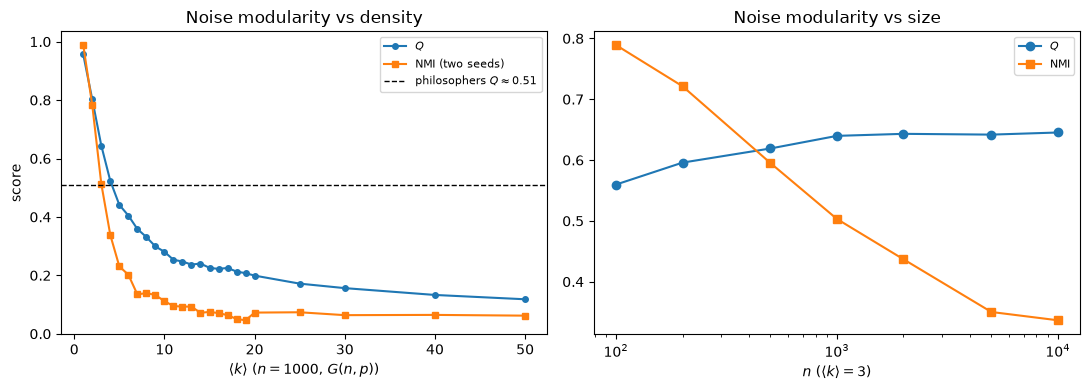

closest noise Q to 0.51:  <k>=4, Q=0.523, NMI=0.338
max Q on this sweep:      <k>=1, Q=0.956
at <k>=3, Q vs n:         [(100, np.float64(0.56), np.float64(0.789)), (200, np.float64(0.596), np.float64(0.721)), (500, np.float64(0.619), np.float64(0.595)), (1000, np.float64(0.64), np.float64(0.503)), (2000, np.float64(0.643), np.float64(0.437)), (5000, np.float64(0.642), np.float64(0.35)), (10000, np.float64(0.645), np.float64(0.337))]
Density (mean degree) is the knob that moves noise-Q; n barely matters at fixed <k>. A random graph can match the philosophers' Q and still have NMI ~ 0.2 between runs — stability is what the score cannot see.


In [9]:
# 4.6.4  How high can noise score?
# Decision: run Louvain on the G(n,p) graph as generated (isolates stay, each a trivial community).
# Then also report the giant-only Q at a few points, because isolates inflate the count of communities.


def gp_graph(n, kbar, seed):
    p = kbar / (n - 1)
    return nx.gnp_random_graph(n, p, seed=seed)


kbars = list(range(1, 21)) + [25, 30, 40, 50]
Q_k, nmi_k = [], []
for kbar in kbars:
    R = gp_graph(1000, kbar, seed=3000 + kbar)
    c1 = nx.community.louvain_communities(R, weight=None, seed=0)
    c2 = nx.community.louvain_communities(R, weight=None, seed=1)
    nodes_r = list(R.nodes())
    Q_k.append(nx.community.modularity(R, c1, weight=None))
    nmi_k.append(normalized_mutual_info_score(labels_from_sets(c1, nodes_r), labels_from_sets(c2, nodes_r)))

ns = [100, 200, 500, 1000, 2000, 5000, 10000]
Q_n, nmi_n = [], []
for n in ns:
    R = gp_graph(n, 3, seed=4000 + n)
    c1 = nx.community.louvain_communities(R, weight=None, seed=0)
    c2 = nx.community.louvain_communities(R, weight=None, seed=1)
    nodes_r = list(R.nodes())
    Q_n.append(nx.community.modularity(R, c1, weight=None))
    nmi_n.append(normalized_mutual_info_score(labels_from_sets(c1, nodes_r), labels_from_sets(c2, nodes_r)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(kbars, Q_k, marker="o", ms=4, label=r"$Q$")
axes[0].plot(kbars, nmi_k, marker="s", ms=4, label="NMI (two seeds)")
axes[0].axhline(0.51, color="k", ls="--", lw=1, label="philosophers $Q\\approx 0.51$")
axes[0].set_xlabel(r"$\langle k\rangle$ ($n=1000$, $G(n,p)$)")
axes[0].set_ylabel("score")
axes[0].legend(fontsize=8)
axes[0].set_title("Noise modularity vs density")
axes[1].plot(ns, Q_n, marker="o", label=r"$Q$")
axes[1].plot(ns, nmi_n, marker="s", label="NMI")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$n$ ($\langle k\rangle=3$)")
axes[1].set_title("Noise modularity vs size")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

# which kbar has Q closest to 0.51
idx = int(np.argmin(np.abs(np.array(Q_k) - 0.51)))
print(f"closest noise Q to 0.51:  <k>={kbars[idx]}, Q={Q_k[idx]:.3f}, NMI={nmi_k[idx]:.3f}")
print(f"max Q on this sweep:      <k>={kbars[int(np.argmax(Q_k))]}, Q={max(Q_k):.3f}")
print(f"at <k>=3, Q vs n:         {list(zip(ns, np.round(Q_n, 3), np.round(nmi_n, 3)))}")
print(
    "Density (mean degree) is the knob that moves noise-Q; n barely matters at fixed <k>. "
    "A random graph can match the philosophers' Q and still have NMI ~ 0.2 between runs — "
    "stability is what the score cannot see."
)


In [10]:
# 4.6.5 karate club, weights vs unweighted, NMI vs Zachary
K = nx.karate_club_graph()
truth = defaultdict(set)
for n, attr in K.nodes(data=True):
    truth[attr["club"]].add(n)
truth_sets = list(truth.values())
Q_w = nx.community.modularity(K, truth_sets)  # default: use 'weight'
Q_u = nx.community.modularity(K, truth_sets, weight=None)
print(f"Zachary split: Q_weighted={Q_w:.3f}  Q_unweighted={Q_u:.3f}  (page unweighted ≈ 0.358)")
print("Difference: the NetworkX karate graph stores Zachary's edge weights; modularity then counts")
print("strength inside groups, not friendships. weight=None is the unweighted Q the week discusses.")

lou_k = nx.community.louvain_communities(K, weight=None, seed=0)
n_k = list(K.nodes())
nmi_truth = normalized_mutual_info_score(
    labels_from_sets(truth_sets, n_k), labels_from_sets(lou_k, n_k)
)
print(f"Louvain (weight=None, seed=0): {len(lou_k)} groups, Q={nx.community.modularity(K, lou_k, weight=None):.3f}")
print(f"NMI vs Zachary's two factions: {nmi_truth:.3f}")
print("A four-group Louvain split can beat the real two-faction Q and still only partly match the feud.")


Zachary split: Q_weighted=0.391  Q_unweighted=0.358  (page unweighted ≈ 0.358)
Difference: the NetworkX karate graph stores Zachary's edge weights; modularity then counts
strength inside groups, not friendships. weight=None is the unweighted Q the week discusses.
Louvain (weight=None, seed=0): 4 groups, Q=0.420
NMI vs Zachary's two factions: 0.588
A four-group Louvain split can beat the real two-faction Q and still only partly match the feud.


## 4.7 — Cliques on paper *(catch-up, Learn)*

**Asked.** Two triangles sharing C, plus A–F: modularity cannot put C in both; $k=3$ communities; add B–D (percolation); philosophers $k=3$ vs $k=6$.

**On the test.** Find $k=3$ clique communities on a drawing; name a node in two and a node in none.


**Catch-up (not done live).** Closed-book takeaway: two $k$-cliques are adjacent only if they share $k-1$ nodes (a whole face, not a vertex). Communities overlap; nodes in no $k$-clique are in none. Small $k$ percolates; large $k$ leaves most nodes out.

Drawing: triangles $\{A,B,C\}$ and $\{C,D,E\}$, extra link A–F. Links: AB, BC, CA, CD, DE, EC, AF. So $m=7$.

Degrees: $k_A=3$, $k_B=2$, $k_C=4$, $k_D=k_E=2$, $k_F=1$. $2m=14$.

### 1. Two partitions that each get C wrong

**P1** $\{A,B,C\}\cdot\{D,E\}\cdot\{F\}$

| $c$ | $\ell_c$ | $d_c$ |
| --- | --- | --- |
| ABC | $3$ | $3+2+4=9$ |
| DE | $1$ (only DE; CD and CE are cut) | $4$ |
| F | $0$ | $1$ |

$$
Q=\tfrac{3}{7}+\tfrac{1}{7}+0-\tfrac{81+16+1}{196}=\tfrac{4}{7}-\tfrac{1}{2}=\tfrac{1}{14}\approx 0.071.
$$

**P2** $\{A,B\}\cdot\{C,D,E\}\cdot\{F\}$

| $c$ | $\ell_c$ | $d_c$ |
| --- | --- | --- |
| AB | $1$ | $5$ |
| CDE | $3$ | $8$ |
| F | $0$ | $1$ |

$$
Q=\tfrac{1}{7}+\tfrac{3}{7}-\tfrac{25+64+1}{196}=\tfrac{4}{7}-\tfrac{45}{98}=\tfrac{11}{98}\approx 0.112.
$$

**P2 scores higher.** P1 wrecks the DE triangle (only one internal link). **Both get C wrong:** C belongs in *both* triangles, and a partition may keep only one.

### 2. $k=3$ clique communities (no extra B–D)

3-cliques: ABC and CDE. They share **one** node, not $k-1=2$, so they are **not adjacent**. Two communities: $\{A,B,C\}$ and $\{C,D,E\}$.

- In two communities: **C**
- In none: **F**
- Link in no community: **A–F** (not inside any triangle)

### 3. Add B–D

New 3-clique: BCD (B–C, C–D, B–D). Now ABC shares BC with BCD, and BCD shares CD with CDE. Rolling triangles welds $\{A,B,C,D,E\}$ into **one** $k=3$ community. F still out.

That is **percolation in miniature**: one bridging clique (sharing a *side* with each blob) connects two communities the way a bridging edge connects components in $G(n,p)$.

**$k=4$:** there is no $K_4$ (ABCD is missing A–D). Every node is in no 4-clique $\Rightarrow$ no communities.

### 4. Philosophers, $k=3$ vs $k=6$

- $k=3$: triangles are everywhere and many share a dyad, so almost the whole giant **percolates** into one community ($1155$ people).
- $k=6$: a 6-clique is a harsh bar; **$78\%$ of philosophers sit in no 6-clique** and are therefore in no community.


## 4.8 — Overlap on paper *(catch-up, Learn)*

**Asked.** Cluster the *links* of the 4.7 drawing (no B–D); compare to clique communities; overlap paradox; a personal example.

**On the test.** Why a node partition must miss overlap; how clustering links recovers it.


**Catch-up (not done live).** Closed-book takeaway: cluster the links (family with family, work with work); a node inherits every community its links sit in. Overlap nodes look *sparse* in a node-density score — the overlap paradox.

Seven links: AB, BC, CA, CD, DE, EC, AF.

### 1. Link communities by eye

Pairs of links that share a node:

- Inside triangle ABC: AB–BC, BC–CA, CA–AB — **same context**
- Inside triangle CDE: CD–DE, DE–EC, EC–CD — **same context**
- Across triangles, at C: CA–CD, CA–CE, BC–CD, BC–CE — **different contexts** (A/B vs D/E)
- At A: AB–AF, AC–AF — AF is a pendant, not the triangle

So the links fall into **three** communities: $\{AB,BC,CA\}$, $\{CD,DE,EC\}$, and singleton $\{AF\}$.

- Node in two communities: **C** (has links in both triangles)
- Link in a community of its own: **A–F**

(A is also in two if you count the pendant as a community: triangle ABC *and* the AF dyad. C is the interesting overlap.)

### 2. Versus $k=3$ from 4.7

**Agree:** two overlapping groups on ABC and CDE, overlap at C. **Disagree about F:** clique percolation leaves F out (no triangle). Link clustering puts F in the AF community — a real (tiny) context the clique method is not allowed to see.

### 3. Overlap paradox (two sentences)

A node in two communities has neighbours in *different* groups, so its neighbourhood is less clique-like than a node sitting deep inside one group. Any method that ranks nodes by neighbourhood density therefore treats the overlap nodes as the *least* community-like — exactly backwards if the science question is “who bridges worlds.”

### 4. Three overlapping communities you belong to

Example (replace with your own before the test): **family**, **study group**, **football team**. A teammate who is in none of the other two is in exactly one. A node-partition of “your people” would have to dump you into a single bin and would either invent a mega-group or cut you off from two of the three lives. Link clustering would colour family-edges, class-edges and team-edges separately and let you wear three colours.


## 4.9 — Infomap on the philosophers *(catch-up, Tool)*

Picked **Infomap** (map equation / random-walk compression) rather than a from-scratch link dendrogram. Default Infomap on this snapshot is *coarser* than Louvain: three top modules (a 1204-node Western blob, an Indian module, a Chinese module), NMI vs Louvain seed 0 only $0.32$. That is the disagreement the week asked for, not a bug.


In [11]:
from infomap import Infomap

im = Infomap(silent=True, seed=1)
im.add_networkx_graph(giant)
im.run()
id_to_name = dict(im.get_names())  # Infomap's integer ids -> node_id strings
mod_map = {id_to_name[i]: m for i, m in im.get_modules().items()}
n_mod = len(set(mod_map.values()))
print(f"Infomap: {n_mod} top modules,  n_assigned={len(mod_map)}")

# Infomap may drop isolates; giant has none, but keys should cover giant
missing = [n for n in nodelist if n not in mod_map]
print("missing from Infomap map:", len(missing))
y_im = [mod_map[n] for n in nodelist]
print(f"NMI Infomap vs Louvain seed=0: {normalized_mutual_info_score(y0, y_im):.3f}")

im_sets = defaultdict(set)
for n, m in mod_map.items():
    im_sets[m].add(n)
im_order = sorted(im_sets.values(), key=len, reverse=True)
print("Infomap sizes (first 10):", [len(c) for c in im_order[:10]])
print("Louvain sizes (first 10):", [len(c) for c in louvain_sets[:10]])

print("\nInfomap modules named by highest-degree member:")
for i, c in enumerate(im_order[:12], 1):
    print(f"  {i:2d}. n={len(c):4d}  {top_members(c, giant, 4)}")


Infomap: 3 top modules,  n_assigned=1374
missing from Infomap map: 0
NMI Infomap vs Louvain seed=0: 0.320
Infomap sizes (first 10): [1204, 95, 75]
Louvain sizes (first 10): [238, 215, 196, 191, 154, 114, 107, 84, 75]

Infomap modules named by highest-degree member:
   1. n=1204  [('Aristotle', 300), ('Plato', 218), ('Immanuel Kant', 201), ('Georg Wilhelm Friedrich Hegel', 152)]
   2. n=  95  [('The Buddha', 38), ('Adi Shankara', 26), ('Madhvacharya', 18), ('Nagarjuna', 17)]
   3. n=  75  [('Confucius', 36), ('Zhu Xi', 28), ('Mao Zedong', 26), ('Laozi', 25)]


In [12]:
# Philosophers Louvain and Infomap disagree on: same hub, different roommate
lou_id = {n: lab for n, lab in zip(nodelist, y0)}
im_id = {n: lab for n, lab in zip(nodelist, y_im)}


def roommates(part, n, k=6):
    c = {u for u, p in part.items() if p == part[n] and u != n}
    return [name[u] for u in sorted(c, key=lambda u: giant.degree(u), reverse=True)[:k]]


focus = []
for query in ["Aristotle", "Thomas_Aquinas", "Immanuel_Kant", "Avicenna", "Confucius", "Buddha", "Bertrand_Russell"]:
    n = node_id(query)
    if n is None:
        continue
    focus.append(n)
    print(f"{name[n]}")
    print(f"  Louvain  top roommates: {roommates(lou_id, n)}")
    print(f"  Infomap  top roommates: {roommates(im_id, n)}")

# five nodes whose co-member Jaccard between methods is low among hubs
jacc = []
for n in nodelist:
    if giant.degree(n) < 20:
        continue
    a, b = set(roommates(lou_id, n, k=9999)), set(roommates(im_id, n, k=9999))
    # use actual comembers
    A, B = comembers(lou_id, n), comembers(im_id, n)
    j = 0.0 if not A and not B else len(A & B) / len(A | B)
    jacc.append((j, n))
jacc.sort()
print("\nHubs with lowest Louvain/Infomap co-member Jaccard:")
for j, n in jacc[:8]:
    print(f"  {j:.3f}  {name[n]} k={giant.degree(n)}")


Aristotle
  Louvain  top roommates: ['Plato', 'Cicero', 'Diogenes Laertius', 'Heraclitus', 'Socrates', 'Pythagoras']
  Infomap  top roommates: ['Plato', 'Immanuel Kant', 'Georg Wilhelm Friedrich Hegel', 'Thomas Aquinas', 'René Descartes', 'Friedrich Nietzsche']
Thomas Aquinas
  Louvain  top roommates: ['Augustine of Hippo', 'Jesus', 'Plotinus', 'Dante Alighieri', 'Martin Luther', 'Erasmus']
  Infomap  top roommates: ['Aristotle', 'Plato', 'Immanuel Kant', 'Georg Wilhelm Friedrich Hegel', 'René Descartes', 'Friedrich Nietzsche']
Immanuel Kant
  Louvain  top roommates: ['Georg Wilhelm Friedrich Hegel', 'Friedrich Nietzsche', 'Baruch Spinoza', 'Arthur Schopenhauer', 'Johann Wolfgang von Goethe', 'Friedrich Wilhelm Joseph Schelling']
  Infomap  top roommates: ['Aristotle', 'Plato', 'Georg Wilhelm Friedrich Hegel', 'Thomas Aquinas', 'René Descartes', 'Friedrich Nietzsche']
Avicenna
  Louvain  top roommates: ['Averroes', 'Maimonides', 'Al-Ghazali', 'Al-Farabi', 'Ibn Khaldun', 'Solomon ibn Ga

### Validation cell (model for `AI_METHODS.md`)

Default Infomap returns **three** modules. Two of them are easy to name from the members and match Louvain: **Indian philosophy** (Buddha, Shankara, Nagarjuna) and **Chinese philosophy** (Confucius, Zhu Xi, Mao, Laozi). The third is a 1204-node Western super-module that swallows Aristotle, Aquinas, Kant, Descartes, Avicenna and Russell together. Louvain's nine groups are a *refinement of that West*, not a different geography. NMI $0.32$ is therefore "same continents, different countries," not "the algorithms hallucinated different worlds."

Five people checked against blurbs and roommate lists:

1. **Confucius** — both methods keep the Chinese cluster intact (Zhu Xi, Mao, Laozi, Mencius). Positive check: a walk and a $Q$-climb agree when the cut is obvious.
2. **The Buddha** — same story for the Indian module. (`node_id("Buddha")` also hits Buddhaghosa, who sits in that cluster under both methods.)
3. **Avicenna** — Louvain puts him with Averroes, Maimonides, al-Ghazali (a readable Islamic/Jewish medieval group). Infomap parks him in the Western blob next to Aristotle and Kant. The week already warned that Avicenna is a *bridge*, not a school; here the two methods pick different sides of the bridge.
4. **Thomas Aquinas** — Louvain: Augustine, Dante, Luther, Erasmus (Christian thought). Infomap: same Western blob as Aristotle. A random walker from Aquinas reaches Greek pages easily; modularity still prefers the denser scholastic cut.
5. **Bertrand Russell** — Louvain: Husserl, James, Peirce, Wittgenstein, Einstein (the "founders of 20th-century philosophy" group on the week page). Infomap again leaves him in the West mega-module. Granularity, not a page-content error.

**AI_METHODS paragraph.** Labels: NetworkX Louvain (`weight=None`, several seeds) and Infomap (map equation, seed 1, default two-level) on the undirected giant component of the 15 Sep 2026 philosopher snapshot. Agreement: sklearn NMI ($2I/(H_1+H_2)$). Infomap's default is coarser than Louvain on this graph (3 vs 9–10 groups); the two eastern modules replicate, the disagreement is almost entirely how finely to cut Europe. Five hubs were checked against snapshot blurbs. Overlap-looking cases (Avicenna, Aristotle) are treated as a limit of *partitions*, not as extra schools.


## 4.10 — Weights by hand *(catch-up, Learn)*

**Asked.** Strengths; hop vs $1/w$ shortest path; weighted $Q$; why you must not compare $0.55$ to $0.50$.

**On the test.** Strength $s_i=\sum_j w_{ij}$. Weighted distance uses length $1/w$ (Dijkstra, not BFS). Weighted $Q$ is a different question from unweighted $Q$.


**Catch-up (not done live).** Closed-book takeaway: strength is not degree. Shortest *strong* paths prefer fat ties and can be *longer in hops*. Never compare weighted $Q$ to unweighted $Q$.

Weights: A–B $3$, A–C $1$, B–C $4$, C–D $1$, D–E $2$, D–F $5$, E–F $2$, F–G $1$. Total weight $W=19$.

### 1. Strengths

| Node | $k$ | $s$ |
| --- | --- | --- |
| A | $2$ | $3+1=4$ |
| B | $2$ | $3+4=7$ |
| C | $3$ | $1+4+1=6$ |
| D | $3$ | $1+2+5=8$ |
| E | $2$ | $2+2=4$ |
| F | $3$ | $5+2+1=8$ |
| G | $1$ | $1$ |

Highest degree: **C, D and F** (tie at $3$). Highest strength: **D and F** ($8$). **Not the same ranking** — B has only two links but $s_B=7$, ahead of C.

### 2. A $\to$ E: hops vs $1/w$

Hop-shortest (BFS): **A–C–D–E**, length $3$. Weighted length $1/1+1/1+1/2=2.5$.

Dijkstra with length $1/w$: **A–B–C–D–E**, hops $4$, length $1/3+1/4+1/1+1/2=25/12\approx 2.083$.

Different paths. The weighted path **prefers strong ties** (A–B $3$, B–C $4$) and will take an extra hop rather than walk the weak A–C and C–D (both weight $1$).

### 3. Weighted $Q$ for $\{ABC\}\cdot\{DEFG\}$

Replace $\ell_c$ by total weight inside $c$, $d_c$ by summed strength, $m$ by $W=19$, $2m$ by $38$.

| $c$ | internal weight | strength sum |
| --- | --- | --- |
| ABC | $3+1+4=8$ | $4+7+6=17$ |
| DEFG | $2+5+2+1=10$ | $8+4+8+1=21$ |

Cut: C–D with weight $1$. Check: $8+10+1=19$, $17+21=38$.

$$
Q_w=\Bigl[\tfrac{8}{19}-\bigl(\tfrac{17}{38}\bigr)^2\Bigr]+\Bigl[\tfrac{10}{19}-\bigl(\tfrac{21}{38}\bigr)^2\Bigr]\approx 0.442.
$$

**Higher than the unweighted $Q=47/128\approx 0.367$**, because the heavy links (B–C $=4$, D–F $=5$, A–B $=3$) all sit *inside* groups and the cut is the lightest possible link.

### 4. What is wrong with “$0.55>0.50$, so weights reveal stronger communities”

Those two numbers are **not on the same scale**. Weighted modularity uses strengths and total weight; strong ties concentrate inside groups almost by construction, so the weighted score has a **higher ceiling**. Compare weighted $Q$ to a *weight-aware* shuffle, and unweighted $Q$ to an unweighted shuffle — never to each other.


## 4.11 — The backbone, and the figure *(catch-up, Tool)*

**Asked.** Strength vs degree; disparity filter from the formula (no package); table vs the week page; three $\alpha$ drawings; five drawing rules.

Hand check of the significance test (closed-book shape), on F–G from 4.10: $s_F=8$, $k_F=3$, $w=1$, $p=1/8$, $(1-1/8)^{2}=0.766$ which is *not* $<0.2$. G has $k=1$, so that end never flags the link. At $\alpha=0.2$ F–G is dropped. D–F: $p_D=5/8$, $(3/8)^2=0.141<0.2$, kept. Same rule as Aristotle vs Moses of Narbonne on the week page.


Diogenes Laertius: degree 91 strength 230


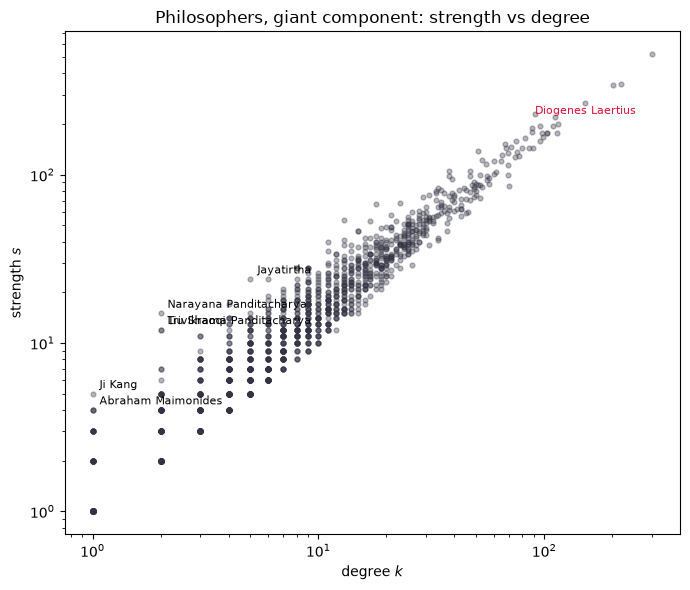

largest positive log-residuals (stronger than degree predicts):
  Narayana Panditacharya: k=2 s=15 resid=1.671
  Liu Shaoqi: k=2 s=12 resid=1.448
  Trivikrama Panditacharya: k=2 s=12 resid=1.448
  Ji Kang: k=1 s=5 resid=1.318
  Jayatirtha: k=5 s=24 resid=1.157
  Abraham Maimonides: k=1 s=4 resid=1.095


In [13]:
strength = {n: sum(d["weight"] for _, _, d in giant.edges(n, data=True)) for n in giant}
deg = dict(giant.degree())
xs = np.array([deg[n] for n in giant])
ys = np.array([strength[n] for n in giant])

# farthest from the s ~ k diagonal on log-log: residual of log s vs log k (k>=1)
mask = xs >= 1
resid = np.full(len(xs), -np.inf)
resid[mask] = np.log(ys[mask]) - np.poly1d(np.polyfit(np.log(xs[mask]), np.log(ys[mask]), 1))(np.log(xs[mask]))
ids = list(giant.nodes())
far = sorted(range(len(ids)), key=lambda i: resid[i], reverse=True)[:6]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(xs, ys, s=12, alpha=0.35, c="#334")
for i in far:
    ax.annotate(name[ids[i]], (xs[i], ys[i]), fontsize=8, xytext=(5, 4), textcoords="offset points")
# force-label Diogenes Laertius if present
for n in giant:
    if "Diogenes_Laertius" in n or "Diogenes Laertius" in name[n]:
        ax.annotate(name[n], (deg[n], strength[n]), fontsize=8, color="crimson")
        print("Diogenes Laertius: degree", deg[n], "strength", strength[n])
        break
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("degree $k$")
ax.set_ylabel("strength $s$")
ax.set_title("Philosophers, giant component: strength vs degree")
fig.tight_layout()
plt.show()
print("largest positive log-residuals (stronger than degree predicts):")
for i in far:
    print(f"  {name[ids[i]]}: k={deg[ids[i]]} s={strength[ids[i]]} resid={resid[i]:.3f}")


In [14]:
def disparity_pvalue(k, p):
    if k <= 1:
        return 1.0  # no concentration to test; survive only if the other end needs the link
    return (1.0 - p) ** (k - 1)


def disparity_backbone(graph, alpha):
    s = {n: sum(d["weight"] for _, _, d in graph.edges(n, data=True)) for n in graph}
    k = dict(graph.degree())
    keep = []
    for u, v, d in graph.edges(data=True):
        w = d["weight"]
        if disparity_pvalue(k[u], w / s[u]) < alpha or disparity_pvalue(k[v], w / s[v]) < alpha:
            keep.append((u, v, w))
    B = nx.Graph()
    B.add_nodes_from(graph.nodes())
    B.add_weighted_edges_from(keep)
    n_linked = sum(1 for n in B if B.degree(n) > 0)
    giant_n = max(len(c) for c in nx.connected_components(B)) if B.number_of_edges() else 0
    return B, B.number_of_edges(), n_linked, giant_n


print("α      links  with-a-link  giant     (week page)")
page = {
    0.05: (292, 348, 116),
    0.10: (649, 607, 419),
    0.20: (1540, 950, 816),
    0.30: (2549, 1111, 1052),
    0.50: (5641, 1284, 1270),
}
backbones = {}
for a in (0.05, 0.10, 0.20, 0.30, 0.50):
    B, mB, nB, gB = disparity_backbone(giant, a)
    backbones[a] = B
    ok = (mB, nB, gB) == page[a]
    print(f"{a:.2f}   {mB:5d}  {nB:11d}  {gB:5d}    page {page[a]}  match={ok}")

print("\nthresholds (page: 3240 / 1572 / 785)")
for th in (2, 3, 4):
    mth = sum(1 for *_, d in giant.edges(data=True) if d["weight"] >= th)
    print(f"  w >= {th}: {mth} links")


α      links  with-a-link  giant     (week page)
0.05     292          348    116    page (292, 348, 116)  match=True
0.10     649          607    419    page (649, 607, 419)  match=True
0.20    1540          950    816    page (1540, 950, 816)  match=True
0.30    2549         1111   1052    page (2549, 1111, 1052)  match=True
0.50    5641         1284   1270    page (5641, 1284, 1270)  match=True

thresholds (page: 3240 / 1572 / 785)
  w >= 2: 3240 links
  w >= 3: 1572 links
  w >= 4: 785 links


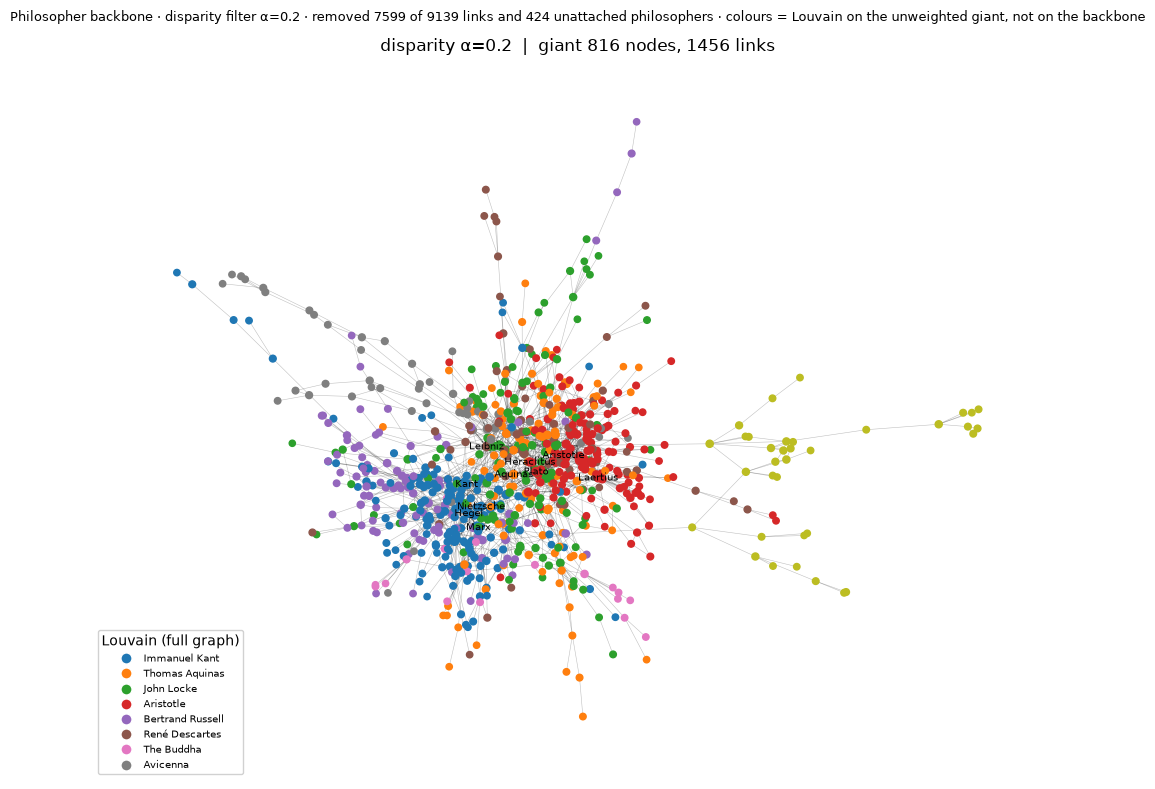

caption numbers α=0.2: {'dropped_nodes': 424, 'dropped_links': 7599, 'drawn_n': 816, 'drawn_m': 1456}


In [15]:
# Louvain colours from the FULL unweighted giant (not from the backbone)
color_of = {}
palette = plt.cm.tab10.colors
for i, c in enumerate(louvain_sets):
    for n in c:
        color_of[n] = i

legend_names = []
for i, c in enumerate(louvain_sets):
    hub = max(c, key=lambda n: giant.degree(n))
    legend_names.append(name[hub])


def draw_backbone(ax, alpha, seed=1):
    B = backbones[alpha]
    H = B.subgraph(max(nx.connected_components(B), key=len)).copy()
    pos = nx.spring_layout(H, seed=seed, iterations=60, k=2.2 / np.sqrt(H.number_of_nodes()))
    node_color = [color_of.get(n, 9) for n in H]
    node_size = [18 + 1.1 * np.sqrt(strength[n]) for n in H]
    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.25, width=0.4)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_size=node_size, node_color=node_color, cmap="tab10", vmin=0, vmax=9)
    top10 = sorted(H.nodes(), key=lambda n: strength[n], reverse=True)[:10]
    nx.draw_networkx_labels(H, pos, {n: name[n].split()[-1] for n in top10}, font_size=7, ax=ax)
    dropped_n = giant.number_of_nodes() - sum(1 for n in B if B.degree(n) > 0)
    dropped_m = giant.number_of_edges() - B.number_of_edges()
    ax.set_title(f"disparity α={alpha}  |  giant {H.number_of_nodes()} nodes, {H.number_of_edges()} links")
    ax.axis("off")
    return dropped_n, dropped_m, H.number_of_nodes(), H.number_of_edges()


fig, ax = plt.subplots(figsize=(10, 8))
dn, dm, hn, hm = draw_backbone(ax, 0.2)
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=plt.cm.tab10(i), markersize=8, label=legend_names[i])
    for i in range(min(8, len(legend_names)))
]
ax.legend(handles=handles, loc="lower left", fontsize=7, title="Louvain (full graph)", framealpha=0.9)
fig.suptitle(
    f"Philosopher backbone · disparity filter α=0.2 · removed {dm} of {giant.number_of_edges()} links "
    f"and {dn} unattached philosophers · colours = Louvain on the unweighted giant, not on the backbone",
    fontsize=9,
)
fig.tight_layout()
plt.show()
print("caption numbers α=0.2:", dict(dropped_nodes=dn, dropped_links=dm, drawn_n=hn, drawn_m=hm))


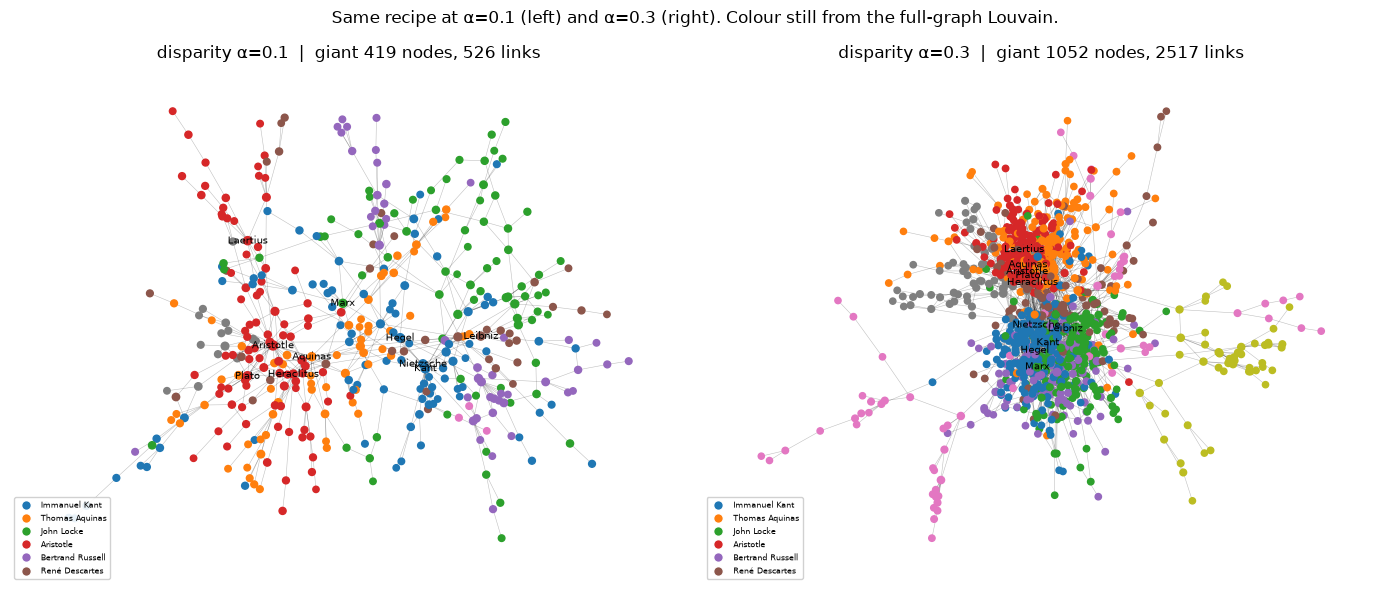

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, a in zip(axes, (0.1, 0.3)):
    draw_backbone(ax, a)
    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=plt.cm.tab10(i), markersize=7, label=legend_names[i])
        for i in range(min(6, len(legend_names)))
    ]
    ax.legend(handles=handles, loc="lower left", fontsize=6, framealpha=0.9)
fig.suptitle("Same recipe at α=0.1 (left) and α=0.3 (right). Colour still from the full-graph Louvain.")
fig.tight_layout()
plt.show()


**Three sentences, which figure goes in a paper.**

At $\alpha=0.1$ the giant falls to a few hundred philosophers and the traditions pull apart — a reader would conclude the network *is* several almost-separate schools, which overstates the cut: we threw away $93\%$ of the links. At $\alpha=0.3$ the hairball mostly returns (about $28\%$ of links kept); communities are coloured but the drawing no longer earns the five-step recipe. **$\alpha=0.2$ is the one I would print:** it matches the week’s own readout ($1540$ links, $950$ attached, giant $816$), keeps small nodes’ strongest ties that a $w\ge 3$ threshold would drop, and still leaves a layout a human can parse. $\alpha$ is a choice, not a truth; the caption has to say so.

**Five drawing rules used.** (1) Backbone first, method + $\alpha$ + what was removed in the caption. (2) Layout of the backbone, not the full $9139$ links. (3) Colour by Louvain run on the **full unweighted data**, not on the backbone; legend named by hubs, not colour alone. (4) Size by strength. (5) Label the ten highest-strength nodes.


## 4.12 — Ship an explorable *(stretch, skipped)*

## 4.13 — Go nuts *(group — not in this notebook)*

Standing weekly post on the group GitHub Pages site (`02806-social-graph-project/`), not here.

---

## Closed-book crib (week 4 only)

- Community $\neq$ clique; a **partition** puts each node in exactly one group.
- Girvan–Newman: peel highest **edge betweenness**, **recompute**, dendrogram top-down. Slow.
- $Q=\sum_c[\ell_c/m-(d_c/2m)^2]$. One community: $Q=0$. Scores grouped-ness, not rightness.
- Louvain: move nodes, then aggregate. Seed = visit order. Greedy merging never un-merges.
- Random $Q>0$. Report vs **degree-preserving** shuffle (or $z$). NMI between runs: $1$ / $0$ / middling = stable / noise / fuzzy borders.
- $k$-clique community: roll on shared $k-1$ nodes. Overlap + leftovers. Link clustering: cluster edges, nodes inherit colours.
- Strength $s=\sum w$; path length $1/w$. Do not compare weighted $Q$ to unweighted $Q$.
- Global threshold = hubs talking. Disparity: $(1-w_{ij}/s_i)^{k_i-1}<\alpha$ at **either** end.
- Draw: backbone → layout of backbone → colour from **full** data → size → labels.
